<a href="https://colab.research.google.com/github/Jayan04-MCC/google_vit_Proyect/blob/master/transformer_python/VisionTransformer_BloodMNIST_(FINAL).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vision Transformer con FashionMNIST



## Importando librerías

In [1]:
import os
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision

import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from tqdm.notebook import tqdm_notebook

## Configurando algunos parámetros:

1.   **Semilla de random (42):** Genera números aleatorios específicos para pruebas (es modificable, pero si se desea probar el caso usar la semilla).
2.   **Configuración determinista de la GPU (torch.backends.cudnn.deterministic = True):** Fuerza a cuDNN (biblioteca de NVIDIA para redes neuronales) a usar algoritmos deterministas, así garantiza que las operaciones de convolución den resultados idénticos en cada ejecución.
3.   **Detección de GPU (device):** Detecta si hay GPU disponible, **Usa GPU** (CUDA) si existe (cuda:0 = primera tarjeta gráfica), en caso contrario **usa CPU.**

In [2]:
# Configurando la semilla
random.seed(42)
g = torch.Generator().manual_seed(2147483647) # por reproducibilidad

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
# Asegurarse de que todas las operaciones son deterministicas en la GPU (si se usa) por reproducibilidad del programa.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print("Device:", device)

Device: cuda:0


# Hiperparametros

In [3]:
image_size = 32  # BloodMNIST tiene imágenes de 32x32
embed_dim=256
hidden_dim=embed_dim*3
num_heads=8
num_layers=6
patch_size=8  # 32/8=4 patches por dimensión (16 patches total)
num_patches=16
num_channels=3  # BloodMNIST es RGB
num_classes=8   # BloodMNIST tiene 8 clases
dropout=0.2

## Descargando BloodMNIST



In [4]:
!pip install -q medmnist

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 62.9 MB/s eta 0:00:00


In [5]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from medmnist import INFO

# Parámetros del dataset
data_flag = 'bloodmnist'
download = True
info = INFO[data_flag]

# Obtener la clase del dataset (dinámicamente)
DataClass = getattr(__import__('medmnist'), info['python_class'])

# Transforms: ToTensor y Normalización para imágenes RGB 3 canales
data_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5, .5, .5], std=[.5, .5, .5])
])

# Cargar datasets
train_dataset = DataClass(split='train', transform=data_transforms, download=download)
val_dataset = DataClass(split='val', transform=data_transforms, download=download)
test_dataset = DataClass(split='test', transform=data_transforms, download=download)

# DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 35.5M/35.5M [00:42<00:00, 835kB/s] 


## Comprobación dimensional:
Debemos verificar que todos los datos (imágenes procesados) tengan las mismas dimensionalidades. En este caso lo hacemos de forma visual, revisando en consola si las dimensiones coinciden.

In [6]:
# Imprimir la dimensión de las imágenes para verificar que todos los cargadores (loaders) tienen las mismas dimensiones.
def print_dim(loader, text):
  print('---------'+text+'---------')
  print(len(loader.dataset))
  for image, label in loader:
    print(image.shape)
    print(label.shape)
    break

print_dim(train_loader,'training loader')
print_dim(val_loader,'validation loader')
print_dim(test_loader,'test loader')

---------training loader---------
11959
torch.Size([32, 3, 28, 28])
torch.Size([32, 1])
---------validation loader---------
1712
torch.Size([32, 3, 28, 28])
torch.Size([32, 1])
---------test loader---------
3421
torch.Size([32, 3, 28, 28])
torch.Size([32, 1])


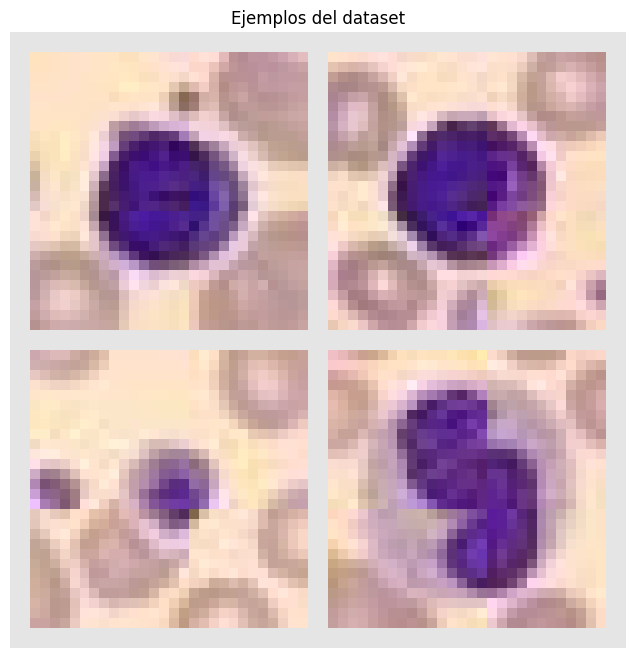

In [7]:
# Ver algunos ejemplos
NUM_IMAGES = 4
MNIST_examples = torch.stack([val_dataset[idx][0] for idx in range(NUM_IMAGES)], dim=0)
img_grid = torchvision.utils.make_grid(MNIST_examples, nrow=2, normalize=True, pad_value=0.9)
img_grid = img_grid.permute(1, 2, 0)

plt.figure(figsize=(8, 8))
plt.title("Ejemplos del dataset")
plt.imshow(img_grid)
plt.axis("off")
plt.show()
plt.close()

## Visualizando la función `img_to_patch`

In [8]:
def img_to_patch(x, patch_size, flatten_channels=True):
    """
    Divide una imagen en parches cuadrado de tamaño patch_size×patch_size.
    Si el tamaño de la imagen no es múltiplo exacto de patch_size, se recorta.
    """
    # Binarizar
    x = (x > 0.5).float()

    B, C, H, W = x.shape

    # Recortar para que sea divisible por patch_size
    H_new = (H // patch_size) * patch_size
    W_new = (W // patch_size) * patch_size
    x = x[:, :, :H_new, :W_new]  # recorte seguro

    # Dividir en parches
    x = x.reshape(B, C, H_new // patch_size, patch_size, W_new // patch_size, patch_size)
    x = x.permute(0, 2, 4, 1, 3, 5)  # [B, H', W', C, p_H, p_W]
    x = x.flatten(1, 2)  # [B, N_patches, C, p_H, p_W]

    if flatten_channels:
        x = x.flatten(2, 4)  # [B, N_patches, C * p_H * p_W]

    return x


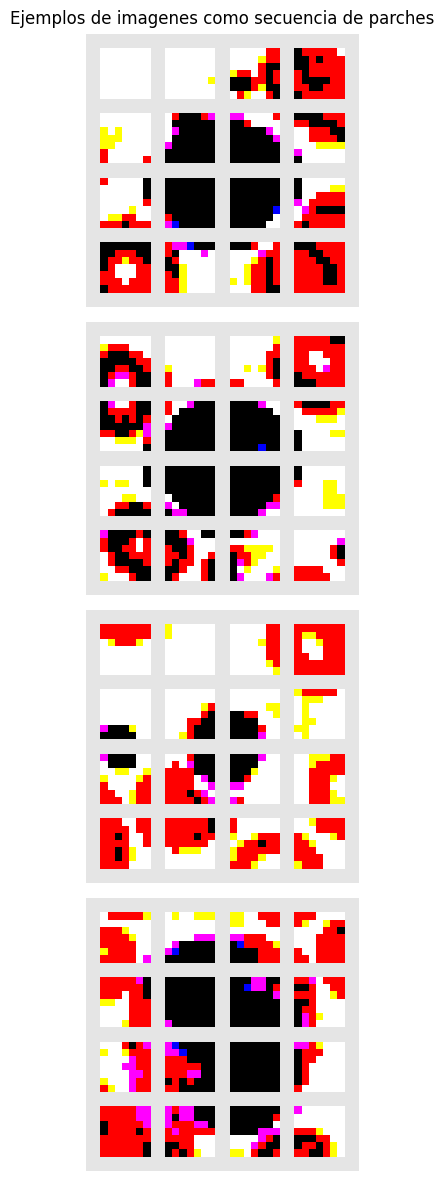

In [9]:
# Configuración
patch_size = 7  # 28x28 / 7x7 = 4x4 parches

# Convertir en parches
img_patches = img_to_patch(MNIST_examples, patch_size=patch_size, flatten_channels=False)

# Visualizar
import matplotlib.pyplot as plt
import torchvision

fig, ax = plt.subplots(MNIST_examples.shape[0], 1, figsize=(14, 12))
fig.suptitle("Ejemplos de imagenes como secuencia de parches")

for i in range(MNIST_examples.shape[0]):
    # Patch grid: [N_patches, C, patch_H, patch_W]
    grid = torchvision.utils.make_grid(img_patches[i], nrow=int(28 / patch_size), normalize=True, pad_value=0.9)
    ax[i].imshow(grid.permute(1, 2, 0))  # [C, H, W] → [H, W, C]
    ax[i].axis("off")

plt.tight_layout()
plt.show()


## Clase VisionTransformer

In [10]:
class AttentionBlock(nn.Module):
    def __init__(self, embed_dim, hidden_dim, num_heads, dropout=0.0):
        """
        Entradas:
            embed_dim - Dimensión de los vectores de características de entrada y de atención
            hidden_dim - Dimensión de la capa oculta en la red feed-forward
                         (usualmente 2 a 4 veces mayor que embed_dim)
            num_heads - Número de cabezas a usar en el bloque de Atención Multi-Cabeza
            dropout - Cantidad de dropout a aplicar en la red feed-forward
        """
        super().__init__()

        self.layer_norm_1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads)
        self.layer_norm_2 = nn.LayerNorm(embed_dim)
        self.linear = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        inp_x = self.layer_norm_1(x)
        x = x + self.attn(inp_x, inp_x, inp_x)[0]
        x = x + self.linear(self.layer_norm_2(x))
        return x

In [11]:
class VisionTransformer(nn.Module):
    def __init__(
        self,
        embed_dim,
        hidden_dim,
        num_channels,
        num_heads,
        num_layers,
        num_classes,
        patch_size,
        num_patches,
        dropout=0.0,
    ):
        """
        Entradas:
            embed_dim - Dimensión de los vectores de características de entrada al Transformer
            hidden_dim - Dimensión de la capa oculta en las redes feed-forward
                         dentro del Transformer
            num_channels - Número de canales de la imagen de entrada (3 para RGB o 1 para escala de grises)
            num_heads - Número de cabezas a usar en el bloque de Atención Multi-Cabeza
            num_layers - Número de capas a usar en el Transformer
            num_classes - Número de clases a predecir
            patch_size - Número de píxeles por dimensión que tiene cada patch
            num_patches - Número máximo de patches que puede tener una imagen
            dropout - Cantidad de dropout a aplicar en la red feed-forward y
                      en el codificado de entrada
        """
        super().__init__()

        self.patch_size = patch_size

        # Layers/Networks
        self.input_layer = nn.Linear(num_channels * (patch_size**2), embed_dim)
        self.transformer = nn.Sequential(
            *(AttentionBlock(embed_dim, hidden_dim, num_heads, dropout=dropout) for _ in range(num_layers))
        )
        self.mlp_head = nn.Sequential(nn.LayerNorm(embed_dim), nn.Linear(embed_dim, num_classes))
        self.dropout = nn.Dropout(dropout)

        # Parameters/Embeddings
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embedding = nn.Parameter(torch.randn(1, 1 + num_patches, embed_dim))

    def forward(self, x):
        # Preprocess input
        x = img_to_patch(x, self.patch_size)        # x.shape ---> batch, num_patches, (patch_size**2)
        B, T, _ = x.shape
        x = self.input_layer(x)                     # x.shape ---> batch, num_patches, embed_dim

        # Add CLS token and positional encoding (atención)
        cls_token = self.cls_token.repeat(B, 1, 1)
        x = torch.cat([cls_token, x], dim=1)        # x.shape ---> batch, num_patches+1, embed_dim
        x = x + self.pos_embedding[:, : T + 1]      # x.shape ---> batch, num_patches+1, embed_dim

        # Apply Transformer
        x = self.dropout(x)
        x = x.transpose(0, 1)                       # x.shape ---> num_patches+1, batch, embed_dim
        x = self.transformer(x)                     # x.shape ---> num_patches+1, batch, embed_dim

        # Perform classification prediction
        cls = x[0]
        out = self.mlp_head(cls)
        return out

## Inicializando el modelo

In [12]:
model = VisionTransformer(embed_dim=embed_dim,
                          hidden_dim=hidden_dim,
                          num_heads=num_heads,
                          num_layers=num_layers,
                          patch_size=patch_size,
                          num_channels=num_channels,
                          num_patches=num_patches,
                          num_classes=num_classes,
                          dropout=dropout)

# Transfer to GPU
model.to(device)
model_restore = None #'/content/model_20230712_211204_0'
if model_restore is not None and os.path.exists(model_restore):
  model.load_state_dict(torch.load(model_restore))
  model.restored = True

In [13]:
model

VisionTransformer(
  (input_layer): Linear(in_features=147, out_features=256, bias=True)
  (transformer): Sequential(
    (0): AttentionBlock(
      (layer_norm_1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (layer_norm_2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (linear): Sequential(
        (0): Linear(in_features=256, out_features=768, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.2, inplace=False)
        (3): Linear(in_features=768, out_features=256, bias=True)
        (4): Dropout(p=0.2, inplace=False)
      )
    )
    (1): AttentionBlock(
      (layer_norm_1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (layer_norm_2): Laye

## Entrenamiento

In [14]:
# setup the loss function
loss_fn = torch.nn.CrossEntropyLoss()
# setup the optimizer with the learning rate
model_optimizer = optim.Adam(model.parameters(), lr=3e-4)
# set a scheduler to decay the learning rate by 0.1 on the 100th 150th epochs
model_scheduler = optim.lr_scheduler.MultiStepLR(model_optimizer,
                                            milestones=[100, 150], gamma=0.1)

In [18]:
# listas para las curvas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_vloss = 1_000_000

for epoch in range(20):
    model.train(True)
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for imgs, labels in tqdm_notebook(train_loader, desc='epoch '+str(epoch)):
        imgs, labels = imgs.to(device), labels.to(device)
        labels = labels.long().squeeze()
        model_optimizer.zero_grad()
        preds = model(imgs)
        loss = loss_fn(preds, labels)
        loss.backward()
        model_optimizer.step()

        running_loss += loss.item()

        # Accuracy cálculo entrenamiento
        _, predicted = torch.max(preds, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)

    avg_train_loss = running_loss / len(train_loader)
    train_acc = correct_train / total_train
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)

    # Scheduler step
    model_scheduler.step()
    model.eval()

    running_vloss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            vinputs, vlabels = vdata
            vinputs, vlabels = vinputs.to(device), vlabels.to(device)

            # 🔧 Arreglar etiquetas
            vlabels = vlabels.squeeze().long()
            if vlabels.ndim > 1 and vlabels.size(1) > 1:
              vlabels = vlabels.argmax(dim=1)

            voutputs = model(vinputs)
            vloss = loss_fn(voutputs, vlabels)
            running_vloss += vloss.item()

            # Accuracy cálculo validación
            _, predicted = torch.max(voutputs, 1)
            correct_val += (predicted == vlabels).sum().item()
            total_val += vlabels.size(0)

    avg_vloss = running_vloss / len(val_loader)
    val_acc = correct_val / total_val
    val_losses.append(avg_vloss)
    val_accuracies.append(val_acc)

    print('Epoch {} => Train Loss {:.4f} | Val Loss {:.4f} | Train Acc {:.2f}% | Val Acc {:.2f}%'.format(
        epoch+1, avg_train_loss, avg_vloss, 100 * train_acc, 100 * val_acc))

    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = '/model_VisionTransformer_MNIST_{}.pt'.format(epoch+1)
        torch.save(model.state_dict(), model_path)


epoch 0:   0%|          | 0/374 [00:00<?, ?it/s]

Epoch 1 => Train Loss 0.9805 | Val Loss 0.9160 | Train Acc 62.25% | Val Acc 65.60%


epoch 1:   0%|          | 0/374 [00:00<?, ?it/s]

Epoch 2 => Train Loss 0.8830 | Val Loss 0.8881 | Train Acc 67.08% | Val Acc 66.06%


epoch 2:   0%|          | 0/374 [00:00<?, ?it/s]

...

Epoch 18 => Train Loss 0.4560 | Val Loss 0.6487 | Train Acc 83.28% | Val Acc 78.15%


epoch 18:   0%|          | 0/374 [00:00<?, ?it/s]

Epoch 19 => Train Loss 0.4342 | Val Loss 0.6955 | Train Acc 84.00% | Val Acc 76.34%


epoch 19:   0%|          | 0/374 [00:00<?, ?it/s]

Epoch 20 => Train Loss 0.4367 | Val Loss 0.7031 | Train Acc 83.88% | Val Acc 76.29%


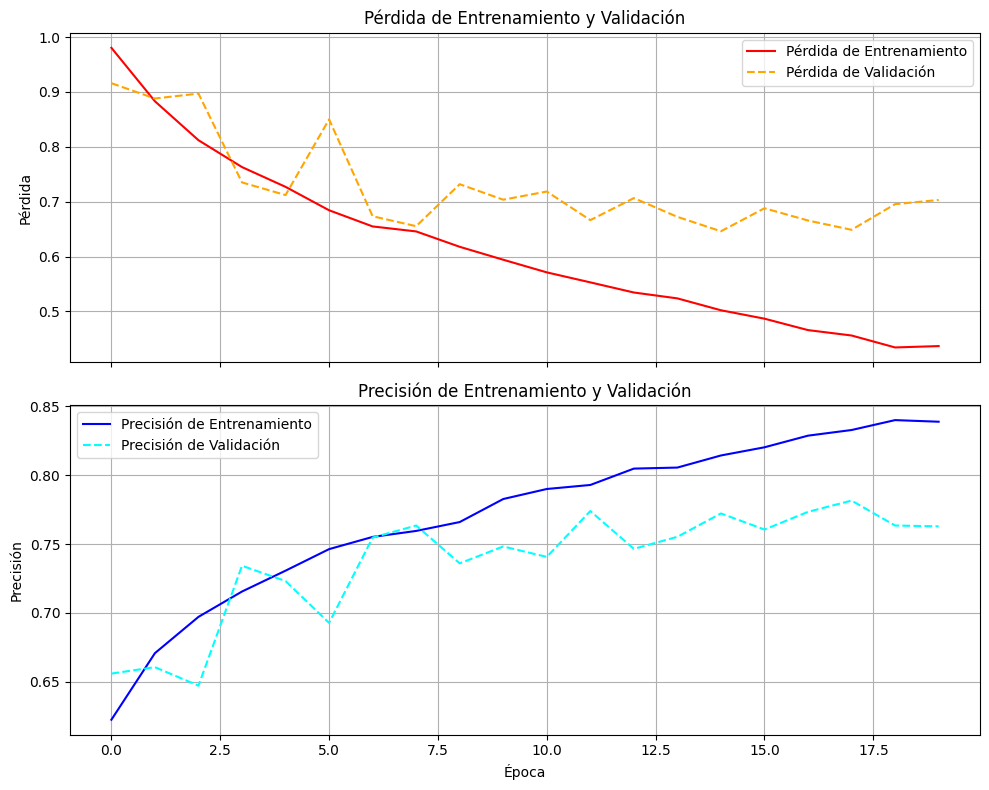

In [19]:
# Convertir listas a tensores (por si usas operaciones de PyTorch)
tl = torch.tensor(train_losses)
vl = torch.tensor(val_losses)
ta = torch.tensor(train_accuracies)
va = torch.tensor(val_accuracies)

# Crear figura con 2 subgráficos (pérdida y precisión)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# === Subgráfico 1: Pérdida ===
ax1.plot(tl, label="Pérdida de Entrenamiento", color='red')
ax1.plot(vl, label="Pérdida de Validación", color='orange', linestyle='--')
ax1.set_ylabel("Pérdida")
ax1.set_title("Pérdida de Entrenamiento y Validación")
ax1.legend()
ax1.grid(True)

# === Subgráfico 2: Precisión ===
ax2.plot(ta, label="Precisión de Entrenamiento", color='blue')
ax2.plot(va, label="Precisión de Validación", color='cyan', linestyle='--')
ax2.set_xlabel("Época")
ax2.set_ylabel("Precisión")
ax2.set_title("Precisión de Entrenamiento y Validación")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


# Pruebas sobre Test

In [20]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Poner el modelo en modo evaluación
model.eval()

# Acumuladores
todas_las_predicciones = []
todas_las_etiquetas = []

with torch.no_grad():
    for imgs, etiquetas in tqdm_notebook(test_loader):
        imgs, etiquetas = imgs.to(device), etiquetas.to(device)
        salidas = model(imgs)
        predicciones = salidas.argmax(dim=1)

        todas_las_predicciones.extend(predicciones.cpu().numpy())
        todas_las_etiquetas.extend(etiquetas.cpu().numpy())

# Calcular métricas
exactitud = accuracy_score(todas_las_etiquetas, todas_las_predicciones)
exactitud_balanceada = balanced_accuracy_score(todas_las_etiquetas, todas_las_predicciones)
precision = precision_score(todas_las_etiquetas, todas_las_predicciones, average='macro')
sensibilidad = recall_score(todas_las_etiquetas, todas_las_predicciones, average='macro')
f1 = f1_score(todas_las_etiquetas, todas_las_predicciones, average='macro')
matriz_confusion = confusion_matrix(todas_las_etiquetas, todas_las_predicciones)

# Reporte
print("\n📊 Métricas de Evaluación en el Conjunto de Prueba:")
print(f"Exactitud:              {exactitud:.4f}")
print(f"Exactitud Balanceada:   {exactitud_balanceada:.4f}")
print(f"Precisión (macro):      {precision:.4f}")
print(f"Sensibilidad (Recall):  {sensibilidad:.4f}")
print(f"Puntaje F1 (macro):     {f1:.4f}")

# Mostrar la matriz de confusión
print("\nMatriz de Confusión:")
print(matriz_confusion)

# Reporte detallado por clase
print("\nReporte de Clasificación Detallado:")
print(classification_report(todas_las_etiquetas, todas_las_predicciones, digits=4))


  0%|          | 0/107 [00:00<?, ?it/s]


📊 Métricas de Evaluación en el Conjunto de Prueba:
Exactitud:              0.7612
Exactitud Balanceada:   0.7385
Precisión (macro):      0.7456
Sensibilidad (Recall):  0.7385
Puntaje F1 (macro):     0.7349

Matriz de Confusión:
[[175   5   2  36  12  14   0   0]
 [ 52 463   5  61   1  23  19   0]
 [ 33  11 176  18  47   0  10  16]
 [ 76  27   4 401   3  46  22   0]
 [ 40   1  18   7 175   1   0   1]
 [ 32   9   1  60   1 181   0   0]
 [  2  29   5  41   0   5 583   1]
 [  0   0  20   0   0   0   0 450]]

Reporte de Clasificación Detallado:
              precision    recall  f1-score   support

           0     0.4268    0.7172    0.5352       244
           1     0.8495    0.7420    0.7921       624
           2     0.7619    0.5659    0.6494       311
           3     0.6426    0.6926    0.6667       579
           4     0.7322    0.7202    0.7261       243
           5     0.6704    0.6373    0.6534       284
           6     0.9196    0.8754    0.8969       666
           7     0.9


## Pruebas de atención:
Con una muestra de prueba y la corremos a través del primer bloque de atención.

In [29]:
labels = torch.tensor(test_dataset.labels.squeeze())  # ahora es tensor 1D
test_sample_index = (labels == 7).nonzero(as_tuple=True)[0][5].item()

In [39]:
# Obtener imagen y etiqueta correctamente
img, label = test_dataset[test_sample_index]

# Añadir dimensión de batch y mover a GPU
img_tensor = img.unsqueeze(0).to(device)  # [1, 1, 28, 28]

# Convertir la muestra en parches
patches = img_to_patch(img_tensor, patch_size=patch_size)

# Pasar por la capa de entrada (embedding)
patches = model.input_layer(patches.float())

# Añadir token de clase y posición
transformer_input = torch.cat((model.cls_token, patches), dim=1) + model.pos_embedding
print("Input tensor to Transformer: ", transformer_input.shape)

# Pasar por la primera capa del Transformer
transformer_input_expanded = model.transformer[0].linear[0](transformer_input).squeeze(0)
print("transformer_input_expanded shape: ", transformer_input_expanded.shape)


Input tensor to Transformer:  torch.Size([1, 17, 256])
transformer_input_expanded shape:  torch.Size([17, 768])


In [40]:
# Redimensionar la salida del primer bloque de atención al tamaño (num_patches+1, 3, num_heads, -1)
qkv = transformer_input_expanded.reshape(num_patches+1, 3, num_heads, -1)
print("qkv shape: ", qkv.shape)

# Extraer la matriz de queries (consultas) y reorganizar las dimensiones a (8 cabezas, 17 patches, 32 canales)
# Hacer lo mismo para la matriz de keys (claves)
q = qkv[:, 0].permute(1, 0, 2)
k = qkv[:, 1].permute(1, 0, 2)
print("q shape: ", q.shape)
print("k shape: ", k.shape)

# Transponer la matriz k para que tenga forma adecuada para el producto con q
kT = k.permute(0, 2, 1)

# El resultado de multiplicar q @ kT es una matriz cuadrada de 17x17 que muestra
# cómo cada patch "presta atención" a cada otro patch
attention_matrix = q @ kT
print("attention matrix: ", attention_matrix.shape)

qkv shape:  torch.Size([17, 3, 8, 32])
q shape:  torch.Size([8, 17, 32])
k shape:  torch.Size([8, 17, 32])
attention matrix:  torch.Size([8, 17, 17])


In [41]:
# Promediar los pesos de atención entre todas las cabezas tomando la media a lo largo
# de la primera dimensión (dim=0)
attention_matrix_mean = torch.mean(attention_matrix, dim=0)
print("attention matrix mean: ", attention_matrix_mean.shape)

# Para tener en cuenta las conexiones residuales, se suma una matriz identidad
# a la matriz de atención y se re-normalizan los pesos.
# Ver el paper de attention rollout: https://arxiv.org/abs/2005.00928
residual_att = torch.eye(attention_matrix_mean.size(1)).to(device)
aug_att_mat = attention_matrix_mean + residual_att
print("augmented attention matrix: ", aug_att_mat.shape)

# Normalizar la matriz de atención aumentada para que cada fila sume 1
aug_att_mat = aug_att_mat / aug_att_mat.sum(dim=-1).unsqueeze(-1)
print("normalized augmented attention matrix: ", aug_att_mat.shape)

attention matrix mean:  torch.Size([17, 17])
augmented attention matrix:  torch.Size([17, 17])
normalized augmented attention matrix:  torch.Size([17, 17])


## Trazando (plotting) attention
Ahora tenemos una matriz cuadrada normalizada de tamaño $17\times 17$. Cuando se traza la primera columna corresponde a la etiqueta de clase (class token).
Las $16$ columnas restantes serán redistribuidas en matrices de $4\times 4$  (patch), ordenadas de tal forma que cada parche (patch) tiene su posición en la imagen.

 Para mejor visualización, usamos la función `interpolate` de forma que redistribuimos las matrices $4\times 4$ en la forma $28\times 28$ (por conveniencia de visualización).

attn_heatmap: torch.Size([4, 4])
attn_heatmap_resized: torch.Size([28, 28])


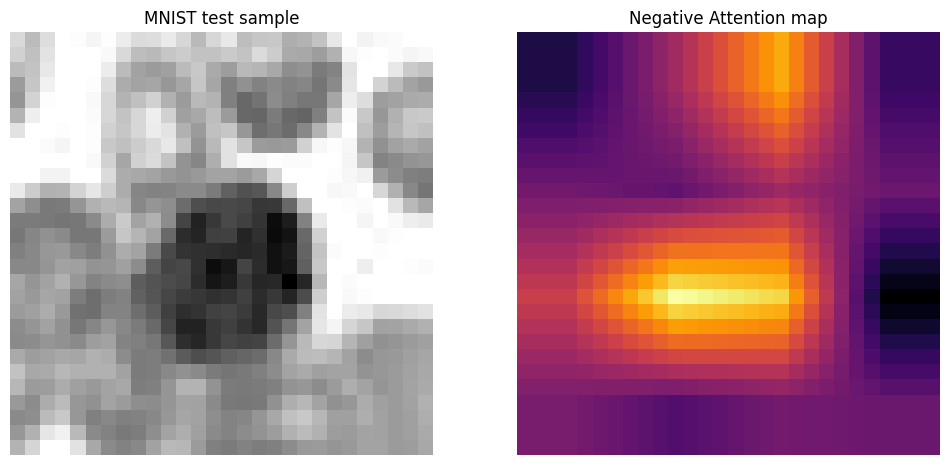

In [47]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Crear heatmap de atención
attn_heatmap = aug_att_mat[0, 1:].reshape((int(image_size / patch_size), int(image_size / patch_size)))
print("attn_heatmap:", attn_heatmap.shape)

# Redimensionar a tamaño 28x28
attn_heatmap_resized = F.interpolate(
    attn_heatmap.unsqueeze(0).unsqueeze(0),
    size=(28, 28),
    mode='bilinear',
    align_corners=False
).squeeze()
print("attn_heatmap_resized:", attn_heatmap_resized.shape)

# Invertir el mapa de atención (hacerlo negativo)
attn_heatmap_neg = -attn_heatmap_resized

# Preparar imagen MNIST
img_array = img_tensor.squeeze().cpu().numpy()
if img_array.ndim == 3:
    img_array = img_array[0]

# Graficar imagen y mapa de atención negativo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Imagen original
ax1.imshow(img_array, cmap='gray')
ax1.set_title('MNIST test sample')
ax1.axis('off')

# Mapa de atención negativo
ax2.imshow(attn_heatmap_neg.detach().cpu().numpy(), cmap='inferno')
ax2.set_title('Negative Attention map')
ax2.axis('off')

plt.show()


# Guardar modelo

In [48]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [49]:
import os
import torch

# Crear carpeta si no existe
ruta_modelo = "/content/drive/MyDrive/modelos"
os.makedirs(ruta_modelo, exist_ok=True)

# Guardar pesos del modelo
nombre_archivo = "modelo_transformer_Bloodmnist.pth"
ruta_completa = os.path.join(ruta_modelo, nombre_archivo)
torch.save(model.state_dict(), ruta_completa)

print(f"✅ Modelo guardado en Google Drive: {ruta_completa}")

✅ Modelo guardado en Google Drive: /content/drive/MyDrive/modelos/modelo_transformer_Bloodmnist.pth
